## Scipy and Optimization

In the last notebook we took a tour of the `numpy` and `scipy` stack as it relates to math and statistics. This notebook is going to focus on another subset of `scipy` functionality that is absolutely critical to data analytics. Nearly every statistical algorithm aside from Ordinary Least Squares (OLS) regression cannot be solved algebraically. Because they cannot be solved algebraically, they must be solved **numerically**.

### Numeric Optimization

Let's start with an example of optimization. Let's say that you know the demand function for tickets to watch a local sports franchise. You can write the inverse demand function as 

$$ P = 300 - \frac{1}{2}Q $$

and the total cost function as 

$$ TC = 4000 + 45Q $$

In order to choose the right number of tickets to sell, you need to calculate the quantity of tickets that will maximize profits. We can calculate total revenue as $ TR = P \times Q $, and we can calculate profit as $ \Pi = TR - TC $. This means that our profit function is 

$$ \Pi = 300Q - \frac{1}{2}Q^2 - 4000 - 45Q $$

In order to find the $Q$ associated with the highest achievable level of profit, we can use calculus to find the point at which the rate of change in the profit function is zero ($\frac{\partial\Pi}{\partial Q}=0$).

$$ \frac{\partial\Pi}{\partial Q} = 300 - Q - 45 = 0 \implies Q = 255$$

So we can **algebraically** solve this particular problem. This isn't always the case. Using `scipy`, we can solve this same problem, as well as many algebraically intractable problems that might be more interesting to us.


<img src="https://github.com/dustywhite7/Econ8320/raw/master/SlidesCode/paraboloid.png" width="200" height="200" />


In any optimization problem, we need to find a way to get ourselves to the minimum, and to know when we get there. When we look at the above image, we are able to visually trace the functional shape (looks like a rainbow ice cream cone to me...) and locate the bottom of the function. What we want to do is utilize an algorithm to "trace" our way from an arbitrary starting point within a function to the optimal point in that function. 

In three or fewer dimensions, this is easy. Regressions and statistical models often live in worlds with 100's or 1000's (even millions sometimes) of dimensions. We can't visualize our way to the bottom of those functions! 

The class of algorithm that is used to solve these problems is called **gradient descent**.

<img src="https://github.com/dustywhite7/Econ8320/raw/master/SlidesCode/gradDesc.png" width="400" />

**Gradient descent** is an algorithm that explores the shape of the function, and determines which direction is most likely to lead to the optimal point. Let's focus on minimization. We want to find our way to the *bottom* of a function, and we can use gradient descent to try to get there. Given any starting point, our goal is to check the direction in which we can move downward most quickly, and start moving in that direction. At some distance from our starting point, we will stop and re-evaluate the direction in which we would like to travel. Are we still heading downhill in the steepest direction? If we aren't, then we need to update our behavior.

Our gradient descent algorithm will keep "looking around" and moving down until it reaches a point at which it can no longer move "down" in any meaningful way. That is the stopping point, and is treated as the optimum.


With an intuitive understanding of how optimization will happen computationally, it's time to learn a bit more about the math and the code that will help us to achieve computational optimization.

Consider a function, $f$, with two variables $x$ and $y$. Because there are two input variables in the function, it has two partial derivatives:

$$ \frac{\partial f}{\partial x} \text{ and } \frac{\partial f}{\partial y} $$

Each partial derivative tells us how $f$ changes as we move in a particular dimension **all else equal**. The **gradient**, then, is the vector of all partial derivatives of a given function at any point along the function:

$$ \nabla f = \left[ \begin{matrix} \frac{\partial f}{\partial x} \\ \\ \frac{\partial f}{\partial y} \end{matrix} \right]  $$

We can use the gradient to determine the linear approximation of a function at any given point. Think about the gradient as the mathematical representation of the slope and direction of a hill you are hiking on. If we know the gradient, we know which way is down. As we continue to calculate gradients while walking, we can continue to ensure that we will walk downhill until we reach the bottom of the hill.




The steps of our gradient descent function will be the following:

- Evaluate the gradient of the function
- Find the direction of steepest descent
- Determine how far to move in that direction
- Move to new point
- Reevaluate the gradient
- Stop moving when gradient is within a margin of error from 0

Let's try to implement gradient descent by solving our old profit maximization problem computationally. The very first thing that we need to do is write a Python function that will represent our mathematical function.

In [2]:
def profit(q):
    p = 300-0.5*q
    tr = p*q
    tc = 4000 + 45*q
    return tr - tc

This function will allow us to calculate profit at any output level based on our assumed total costs and demand curve. With this function, we can quickly calculate the gradient (in this case, just a simple derivative because our function is univariate) by calculating profit at two nearby points, and dividing by the horizontal distance between those points:

In [3]:
# Gradient at q=200

(profit(201) - profit(199))/2

55.0

    55.0



Thus, a one unit increase in output at $Q=200$ results in a $55 increase in profits. This is cool, but it isn't enough for us to find the point of maximum profit (the optimal point). For that, we will need to calculate LOTS of gradients in order to move along the function until we cannot increase profits any further.

Fortunately for us, `scipy` comes with optimization tools that will do all of the heavy lifting of the "search" for the optimal point. All that we need to do is frame our question algorithmically, and let `scipy` do the rest:

In [4]:
import numpy as np
from scipy.optimize import minimize

We start by importing the `minimize` function from `scipy.optimize`. Hang on! Weren't we working on a MAXIMIZATION problem?? What are we doing here?

Maximization and minimization are the **same thing**. To maximize a function, you can multiply that function by `-1` and then calculate the minimum of the new "upside-down" function. It is functionally equivalent. So, in computational optimization, we always minimize.

### Prepping for optimization

As we prepare to optimize, there are two common problems with our function that we may need to resolve:

1) When using `minimize` we can only pass an array of inputs, so we have to be careful to write our function accordingly
2) Our problem is concave, and so has a maximum
	- We need to restate it as a minimization problem

Problem 1 does not apply, since our function in univariate. In order to make our problem a minimization problem, we can flip our profit maximization function. We will simply return -1 * profit:

In [5]:
def profit(q):
    p = 300-0.5*q
    tr = p*q
    tc = 4000 + 45*q
    pi =  tr - tc # didn't name it profit because that is our function's name! Don't want to clutter our name space!
    return -1*pi

### Making the call to `minimize`

Now that our function is ready, it is time to minimize! The `minimize` function takes two arguments:
1. Our function that we want to optimize
2. A starting guess (as a vector)

Let's give it a try.

In [6]:
res = minimize(profit, [0]) # provide function and starting inputs
res

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -28512.499999980355
        x: [ 2.550e+02]
      nit: 3
      jac: [ 0.000e+00]
 hess_inv: [[ 1.000e+00]]
     nfev: 14
     njev: 7

          fun: -28512.499999980355
     hess_inv: array([[1.00000175]])
          jac: array([0.])
      message: 'Optimization terminated successfully.'
         nfev: 21
          nit: 3
         njev: 7
       status: 0
      success: True
            x: array([255.00019821])



That's it! No calculus, no searching, no checking gradients manually. `minimize` simply takes our function and our starting guess and brings us back the optimal choice. We get lots of information stored in the attributes of the `res` object:

- `fun` provides the value of the function (this is -1 times the profit level at the optimal output in our example)
- `hess_inv` and `jac` are measures of gradient and are used to determine how far to go and in which direction
- `message` should be self-explanatory
- `nfev` is the number of times the function (in this case `profit`) was evaluated during the search
- `nit` is the number of iterations it took to find the optimum
- `njev` is the number of times the Jacobian was estimated
- `status` is a code associated with the `message` and `success` atrributes
- `success` tells you whether or not an optimum was found (sometimes it cannot be easily found!)
- `x` probably the most important attribute. This tells us the optimal input value (in our case $Q$), or set of values depending on our function. In a regression context, this could represent the fitted coefficients!

Going forward, you will realize (especially because so many of them print the output as they optimize) just how many libraries in Python use this minimize function behind the scenes. It is used in `statsmodels`, `sklearn`, and many other high-profile libraries! Now that you know where it really happens (in `scipy`!), you'll be better able to troubleshoot the problems that will inevitably arise as you use statistical models.

**Solve-it!**

In this lesson we learned about optimization using SciPy. For the assignment this week, I would like you to build off of your `RegressionModel` class. You will add a Logistic Regression (Logit) method to your class, so that when the `regression_type` parameter is `logit`, Logistic Regression Results are returned. 

Your job is to create the following functionality within your class object:
- a method (call it `logistic_regression`) that estimates the results of logistic regression using your `x` and `y` data frames, and using a likelihood function and gradient descent (DO NOT USE PREBUILT REGRESSION FUNCTIONS).
    - You need to write a function to calculate the Log-likelihood of your model
    - You need to implement gradient descent to find the optimal values of beta
    - You need to use your beta estimates, the model variance, and calculate the standard errors of the coefficients, as well as Z statistics and p-values
    - the results should be stored in a dictionary named `results`, where each variable name (including the intercept if `create_intercept` is `True`) is the key, and the value is another dictionary, with keys for `coefficient`, `standard_error`, `z_stat`, and `p_value`. The coefficient should be the log odds-ratio (which takes the place of the coefficients in OLS)
- a method called `fit_model` that uses the `self.regression_type` attribute to determine whether or not to run an OLS or Logistic Regression using the data provided. This method should call the correct regression method.
- an updated method (call it `summary`) that presents your regression results in a table
    - Columns should be: Variable name, Log odds-ratio value, standard error, z-statistic, and p-value, in that order.
    - Your summary table should have different column titles for OLS and Logistic Regressions! (think if statement...)

You only need to define the class. My code will create an instance of your class (be sure all the names match these instructions, and those from last week!), and provide data to run a regression. I will provide the same data to you, so that you can experiment and make sure that your code is functioning properly.

NOTE: I have created a [primer on Logistic regression](https://github.com/dustywhite7/Econ8320/blob/master/SlidesPDF/9-2%20-%20Logit%20Primer.pdf) to go with this assignment. See the Github slidesPDF folder

Put the code that you would like graded in the cell labeled `#si-exercise`. I recommend copying your code from the last assignment (in chapter 9 about linear regression and `numpy`), and continuing from there. 



In [6]:
#si-exercise

import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import norm

class RegressionModel:
    def __init__(self, x, y, create_intercept=True, regression_type='ols'):
        self.x = x.copy()
        self.y = y.copy()
        self.regression_type = regression_type
        self.create_intercept = create_intercept

        # ensure lowercase intercept name (tests expect 'intercept')
        if create_intercept:
            self.x.insert(0, 'intercept', 1)

        self.results = {}

    # ---------- OLS ----------
    def ols_regression(self):
        X = self.x.values
        y = self.y.values.reshape(-1, 1)

        beta_hat = np.linalg.inv(X.T @ X) @ (X.T @ y)
        y_hat = X @ beta_hat
        residuals = y - y_hat

        n, k = X.shape
        sigma2 = float((residuals.T @ residuals) / (n - k))
        var_beta = sigma2 * np.linalg.inv(X.T @ X)
        se_beta = np.sqrt(np.diag(var_beta))

        t_stats = beta_hat.flatten() / se_beta
        p_values = 2 * (1 - norm.cdf(np.abs(t_stats)))

        self.results = {}
        for i, col in enumerate(self.x.columns):
            self.results[col] = {
                'coefficient': float(beta_hat[i]),
                'standard_error': float(se_beta[i]),
                't_stat': float(t_stats[i]),
                'p_value': float(p_values[i])
            }

    # ---------- Logistic Regression ----------
    def logistic_regression(self):
        X = self.x.values
        y = self.y.values.reshape(-1, 1)
        n, k = X.shape

        def sigmoid(z):
            return 1 / (1 + np.exp(-z))

        def neg_log_likelihood(beta):
            z = X @ beta.reshape(-1, 1)
            p = sigmoid(z)
            p = np.clip(p, 1e-8, 1 - 1e-8)
            ll = np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
            return -ll

        def gradient(beta):
            z = X @ beta.reshape(-1, 1)
            p = sigmoid(z)
            grad = X.T @ (p - y)
            return grad.flatten()

        # estimate betas with minimize (BFGS; gradient provided)
        beta_init = np.zeros(k)
        res = minimize(neg_log_likelihood, beta_init, jac=gradient, method='BFGS')
        beta_hat = res.x.reshape(-1, 1)

        # ----- variance/SE: use instructor's recommended approach -----
        # s_hat = n * ybar * (1 - ybar)
        ybar = float(np.mean(y))
        s_hat = n * ybar * (1 - ybar)

        # Use OLS-style covariance scaled by s_hat: Var(beta) = s_hat * (X'X)^{-1}
        xtx_inv = np.linalg.inv(X.T @ X)
        var_beta = s_hat * xtx_inv
        se_beta = np.sqrt(np.diag(var_beta))

        # z-stats and two-sided p-values
        z_stats = beta_hat.flatten() / se_beta
        p_values = 2 * (1 - norm.cdf(np.abs(z_stats)))

        self.results = {}
        for i, col in enumerate(self.x.columns):
            self.results[col] = {
                'coefficient': float(beta_hat[i]),
                'standard_error': float(se_beta[i]),
                'z_stat': float(z_stats[i]),
                'p_value': float(p_values[i])
            }

    # ---------- Fit Model ----------
    def fit_model(self):
        if self.regression_type == 'ols':
            self.ols_regression()
        elif self.regression_type == 'logit':
            self.logistic_regression()
        else:
            raise ValueError("regression_type must be 'ols' or 'logit'")

    # ---------- Summary ----------
    def summary(self):
        # Tests expect a header that mentions Coeff/Std/Z/P (case-insensitive)
        if self.regression_type == 'ols':
            print("Ordinary Least Squares Regression Results\n")
            print(f"{'Variable':<15}{'Coefficients':<15}{'Std. Error':<15}{'t-Stat':<12}{'P-Value':<12}")
            for var, vals in self.results.items():
                print(f"{var:<15}{vals['coefficient']:<15.6f}{vals['standard_error']:<15.6f}{vals['t_stat']:<12.6f}{vals['p_value']:<12.6f}")
        else:
            print("Logistic Regression Results\n")
            # Use "Coefficients" label so autograder regex for 'Coef' matches
            print(f"{'Variable':<15}{'Coefficients':<18}{'Std. Error':<15}{'Z-Stat':<12}{'P-Value':<12}")
            for var, vals in self.results.items():
                print(f"{var:<15}{vals['coefficient']:<18.6f}{vals['standard_error']:<15.6f}{vals['z_stat']:<12.6f}{vals['p_value']:<12.6f}")


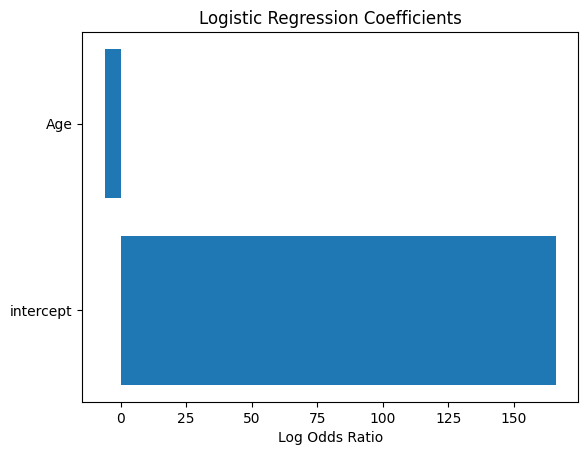

In [14]:
import matplotlib.pyplot as plt

# Example plot
coefs = [v['coefficient'] for v in model.results.values()]
vars_ = list(model.results.keys())
plt.barh(vars_, coefs)
plt.xlabel("Log Odds Ratio")
plt.title("Logistic Regression Coefficients")
plt.show()


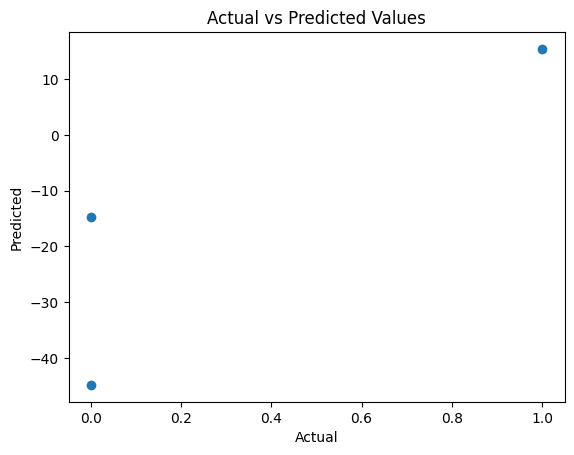

In [15]:
y_hat = model.x.values @ np.array([v['coefficient'] for v in model.results.values()]).reshape(-1,1)
plt.scatter(model.y, y_hat)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Values")
plt.show()
